In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
import numpy as np
from rdkit.Chem.Draw import IPythonConsole
import json
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, rdFMCS
from typing import Callable
# import psiresp
# import nglview as nv
import MDAnalysis as mda
import glob
import re
import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import display, clear_output
sys.path.append(os.path.abspath("../../espaloma-charge_mod/"))
sys.path.append(os.path.abspath('../')) 
import param_tool as pt
from espaloma_charge import charge

IPythonConsole.ipython_useSVG = True
IPythonConsole.molSize = (600, 400)

In [2]:
!pwd

/trinity/home/_shared/_projects/2022_md_FRET_nv/AI_param_tool/notebooks_and_examples/AF_546_cys


# Протокол расчета парциальных зарядов для модифицированных аминокислот
На вход подаються .smi-файлы мономера и полимеров аминокислоты, где аминокислота входит в состав полимера в положениях N M C. 
У мономера должны бать группы COO<sup>-</sup> и N<sup>+</sup>H<sub>3</sub>. У полимеров соответствующие группы на С и N концах.  

In [3]:
PTM_name = 'C_AF546'
base_name = '546'

## Шаг 1 Открытие .smi-файлов 
Мы рекомендуем использовать словари для записи фаилов молекул, также можно передать путь к  `.smi` в виде строки или листа. На выход вы получите словарь с соответствующими ключами. 

In [4]:
monomer_smi = pt.read_file(f'molecules/C_AF_546.smiles')
# monomer_smi =mon_name.read_file('moleculse/R_CIT.smiles')
trimers_smi = pt.read_file([
                            f'molecules/ACA_AF_546.smiles', 
                            # 'moleculse/GRG_CIT.smiles',
                            # 'moleculse/GR_CIT.smiles',

                           ],)
monomer_chem = pt.smi_to_chem(monomer_smi) # RDKit читает smi строку, переводит в chem и добавляет протоны
trimers_chem = pt.smi_to_chem(trimers_smi)
trimers_chem

{'ACA_AF_546': <rdkit.Chem.rdchem.Mol at 0x1553ec74ac00>}

In [5]:
# os.path.basename('moleculse/AKA_1M.smiles').split('.')[0]
mon_name = str(*monomer_smi.keys())
pol_name = str(*trimers_smi.keys())
print(mon_name, pol_name, sep='\n')

C_AF_546
ACA_AF_546


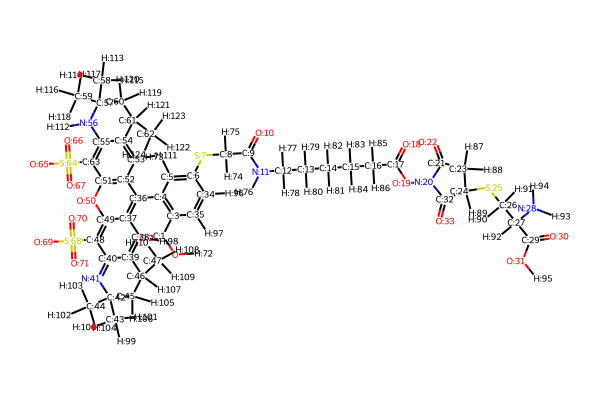

In [6]:
pt.draw_mol_with_atom_index(monomer_chem[mon_name])

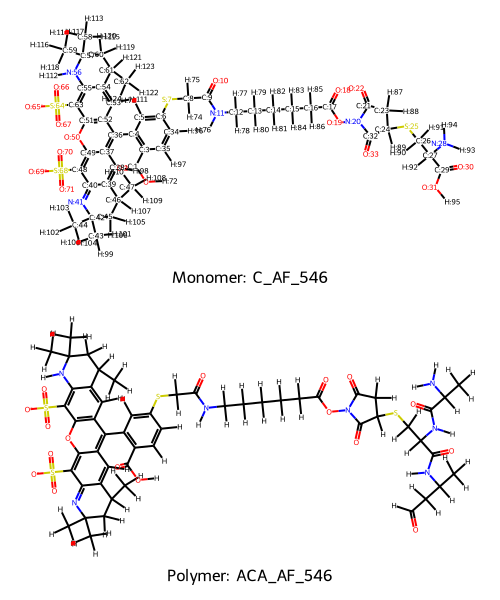

In [7]:
pt.draw_mon_pol_match(monomer_chem, trimers_chem, add_atom_index=True)

## Шаг 2 Поиск подструктур мономера а.к. в полмерах
Наша задача выделить те атомы в составе полимеров, которые входят в состав мономера. Для этого функция `match_mon_to_pol` принимает на вход пару словарей с `Chem` фаилами. Словарь мономеров (один мономер) и полимеров (от 1 до ∞) соответственно. На выход подается словарь с ключами: `substructure`, `mon_pol_matches`, `N_match_atoms`, для кажого из полимеров. \
Где:
- `substructure` - сожердит общие подструктуры мономера и полимера, для каждого из полимеров в формате Chem .
- `mon_pol_matches` - содержит словари соответствия номеров атомов в общей подструктуре с номерами атомов в полимере молекула из общей подструктуры.
- `N_match_atoms` - количество общих атомов для мономера и полимера.\ 
(обычно вам не понадобится этот ключ, но он используется для подсвечивания общей структуры полимера на мономере)

Обратите внимание что набор атомов подструктур внутри мономера различается в зависимости от расположения а.к. в полимере

In [8]:
# substructure_dict, dict_matches = pt.match_chem_v2(monomer_chem[mon_name], trimers_chem[pol_name], timeout= 3)

In [9]:
match_dict = pt.match_mon_to_pol(monomer_chem, trimers_chem, timeout= 3)
# match_dict
# print(match_dict.keys(),match_dict['substructure'],match_dict, sep='\n')

Выполнение Поиск подструктуры между молекулами...
Поиск подструктуры между молекулами выполнен успешно!


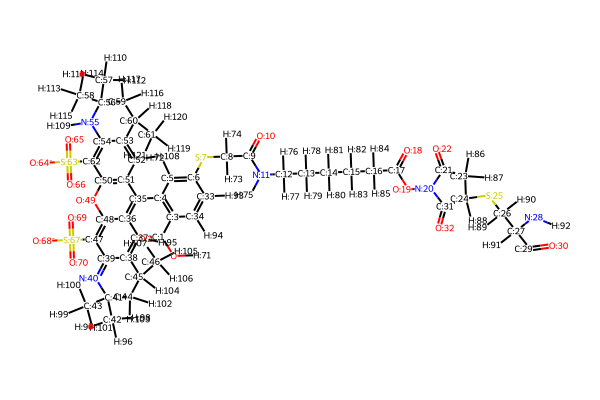

In [10]:
pt.draw_mol_with_atom_index(match_dict['substructure'][mon_name])

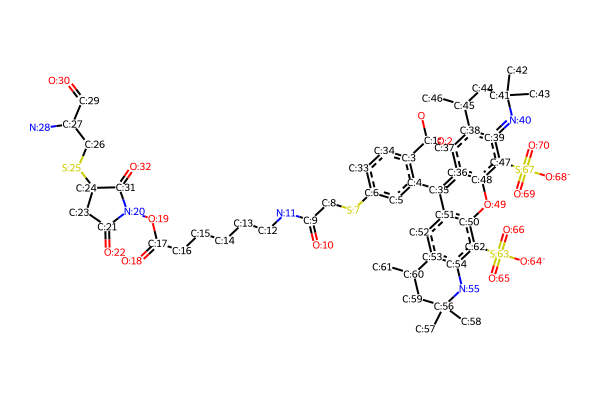

In [11]:
pt.draw_mol_with_atom_index(match_dict['substructure_noH'][mon_name])

### Отрисовка полученных подструктур на молекулах мономера и полимера
Позволяет убедится в корректности структур

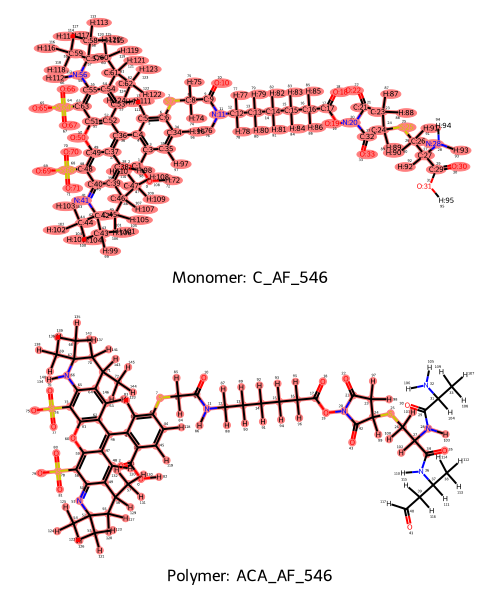

In [12]:
pt.draw_mon_pol_match(monomer_chem, trimers_chem, match_dict, 
                      add_small_atom_index=True, prefer_coord_gfen= False)

## Шаг 3 Сохранение молекул подструктур для N M С позиций 

Из молекулы мономера были выделены структуры аминокислот для каждой из позиций `N` `M` `C`. Важно ответить, что при созранение подструктур идет переупордочивание атомов таким образом, что первым атомом в молекуле становится автом **N** в составе аминогруппы. Далее имено они будут использоваться при получении файлов топологии. \
Ниже представленно несколько вариантов сохранения подструктур, но в итоге будут использоватсья файлы формата `.pdb` 

Были получены молекулярные формулы параметризируемых остатков `match_dict['substructure']`. Именно они будут использоваться для получения фаилов топологии в следующем ноутбуке.

#### Сохранение подструктур в виде **smiles**

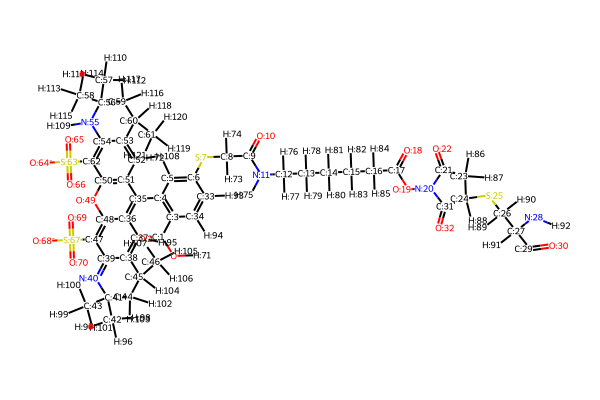

In [13]:
pt.draw_mol_with_atom_index(match_dict['substructure'][mon_name])

In [14]:
for chem_name, chem_mol in  match_dict['substructure'].items():
    print(chem_name, chem_mol)
    pt.save_aa_chem_to_smiles(chem_mol, f'molecules/substructure/{chem_name}',
                              canonical=False ,make_N_root=False)

C_AF_546 <rdkit.Chem.rdchem.Mol object at 0x1553eb44ed50>
C_AF_546.smiles saved to molecules/substructure


##### Проверка сохраненных подструктур

In [15]:
test_smi = pt.read_file([f'molecules/substructure/{mon_name}.smiles',
                        ])
test_chem = pt.smi_to_chem(test_smi, addH=False, sanitize=False, make_N_root=False)
IPythonConsole.drawOptions.addAtomIndices = False

TypeError: smi_to_chem() got an unexpected keyword argument 'make_N_root'

In [16]:
pt.draw_mol_with_atom_index(test_chem[mon_name])

NameError: name 'test_chem' is not defined

### Сохранение подструктур в виде **pdb**

То как выглядит подструктура для одного из вариантов позиционирования остатка в цепи:

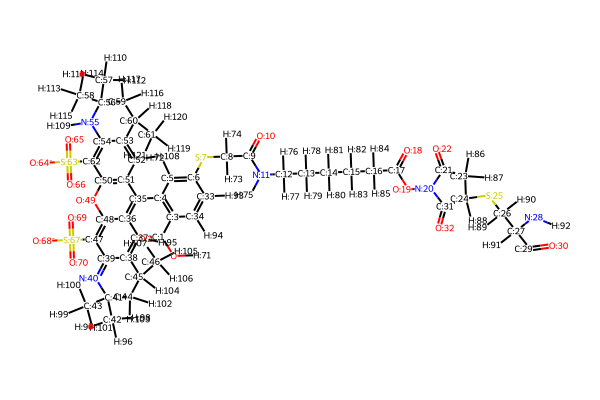

In [17]:
pt.draw_mol_with_atom_index(match_dict['substructure'][mon_name])

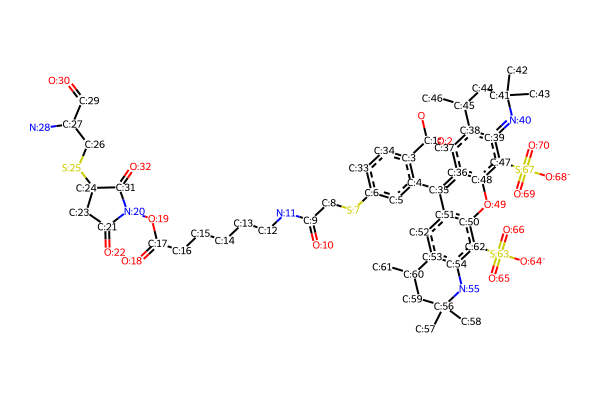

In [18]:
pt.draw_mol_with_atom_index(match_dict['substructure_noH'][mon_name])

In [19]:
new_mol_H = pt.renumber_amino_acid_atoms(match_dict['substructure'][mon_name])
new_mol_no_H = pt.renumber_amino_acid_atoms(match_dict['substructure_noH'][mon_name])

In [20]:
match_dict['substructure'][mon_name] = new_mol_H
match_dict['substructure_noH'][mon_name] = new_mol_no_H

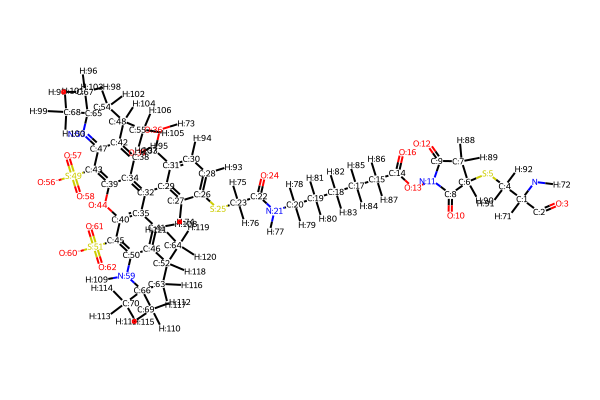

In [21]:
pt.draw_mol_with_atom_index(match_dict['substructure'][mon_name])

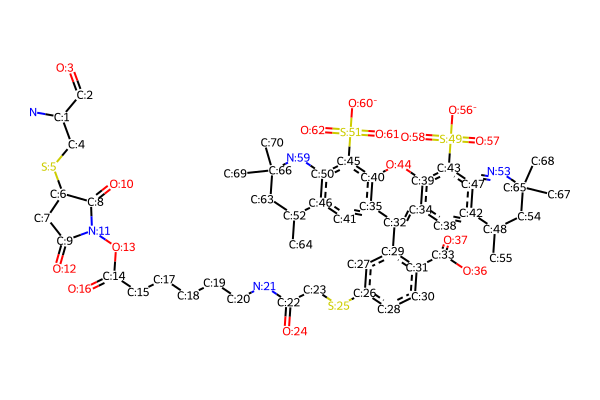

In [22]:
pt.draw_mol_with_atom_index(match_dict['substructure_noH'][mon_name])

Сохранение подструктуры (т.е. атомов входящих в состав модифицированного остатка в зависимости от его позиции в полимере) в формате 
`pdb`. \
Далее полученные ДНК используются для получения парциальных зарядов и для получения файлов топологии. \
Кроме этого вы можете взять их и использовать в молекулярном  моделировании для добавления модифицированного остатка в вашу структуру.   

##### Одиночное сохранение:
Мы сохраняем остаток ак в составе которго атомы только входящие в этот остаток. \
Все имен аатомов уникальные

In [23]:
pt.save_substructure_mol(match_dict, f'molecules/substructure', [mon_name],
                         resname = base_name, resid = 2, segid = 'A')

[16:16:59] Molecule does not have explicit Hs. Consider calling AddHs()
[16:17:00] Molecule does not have explicit Hs. Consider calling AddHs()



Уровень 1: 1 атомов
  Буква уровня: B
    CB (бывший) -> CB (индекс 1)
      водород HB1
      водород HB2

Уровень 2: 1 атомов
  Буква уровня: G
    SG (бывший) -> SG (индекс 1)

Уровень 3: 1 атомов
  Буква уровня: D
    CD (бывший) -> CD (индекс 1)
      водород HD

Уровень 4: 2 атомов
  Буква уровня: E
    CE (бывший) -> CE1 (индекс 1)
      водород HE11
      водород HE12
    CE (бывший) -> CE2 (индекс 2)

Уровень 5: 3 атомов
  Буква уровня: Z
    CZ (бывший) -> CZ1 (индекс 1)
    OZ (бывший) -> OZ2 (индекс 2)
    NZ (бывший) -> NZ3 (индекс 3)

Уровень 6: 2 атомов
  Буква уровня: H
    OH (бывший) -> OH1 (индекс 1)
    OH (бывший) -> OH2 (индекс 2)

Уровень 7: 1 атомов
  Буква уровня: T
    CT (бывший) -> CT (индекс 1)

Уровень 8: 2 атомов
  Буква уровня: I
    CI (бывший) -> CI1 (индекс 1)
      водород HI11
      водород HI12
    OI (бывший) -> OI2 (индекс 2)

Уровень 9: 1 атомов
  Буква уровня: K
    CK (бывший) -> CK (индекс 1)
      водород HK1
      водород HK2

Уровень 10: 

[16:17:01] Molecule does not have explicit Hs. Consider calling AddHs()
[16:17:01] Molecule does not have explicit Hs. Consider calling AddHs()



Уровень 1: 1 атомов
  Буква уровня: B
    CB (бывший) -> CB (индекс 1)

Уровень 2: 1 атомов
  Буква уровня: G
    SG (бывший) -> SG (индекс 1)

Уровень 3: 1 атомов
  Буква уровня: D
    CD (бывший) -> CD (индекс 1)

Уровень 4: 2 атомов
  Буква уровня: E
    CE (бывший) -> CE1 (индекс 1)
    CE (бывший) -> CE2 (индекс 2)

Уровень 5: 3 атомов
  Буква уровня: Z
    CZ (бывший) -> CZ1 (индекс 1)
    OZ (бывший) -> OZ2 (индекс 2)
    NZ (бывший) -> NZ3 (индекс 3)

Уровень 6: 2 атомов
  Буква уровня: H
    OH (бывший) -> OH1 (индекс 1)
    OH (бывший) -> OH2 (индекс 2)

Уровень 7: 1 атомов
  Буква уровня: T
    CT (бывший) -> CT (индекс 1)

Уровень 8: 2 атомов
  Буква уровня: I
    CI (бывший) -> CI1 (индекс 1)
    OI (бывший) -> OI2 (индекс 2)

Уровень 9: 1 атомов
  Буква уровня: K
    CK (бывший) -> CK (индекс 1)

Уровень 10: 1 атомов
  Переход в numeric режим на глубине 10
    C -> C19 (numeric)

Уровень 11: 1 атомов
    C -> C20 (numeric)

Уровень 12: 1 атомов
    C -> C21 (numeric)

Ур

##### Множественное сохранение:

In [24]:
sub_name = ['NR_CIT_1', 'R_CIT_1', 'CR_CIT_1']
resname_l = ['NRC', 'RC', 'CRC']
for chem_name, chem_mol, resname in zip(sub_name, match_dict['substructure'].values(), resname_l):
    pt.save_aa_chem_to_pdb(chem_mol, f'moleculse/substructure/{chem_name}_rdkit', resname = resname, make_N_root=True)

TypeError: save_aa_chem_to_pdb() got an unexpected keyword argument 'make_N_root'

#### Проверка сохраненных молекул

In [17]:
if '_H' in mon_name:
    mon_name_no_H = mon_name.replace('_H','_no_H')
else:
    mon_name_no_H = mon_name + '_no_H'

In [18]:

renamed_base = pt.pdb_to_chem([
            f'molecules/substructure/{mon_name}.pdb',
            f'molecules/substructure/{mon_name_no_H}.pdb'
                          ])
renamed_base

{'C_AF_546': <rdkit.Chem.rdchem.Mol at 0x1553f0092a40>,
 'C_AF_546_no_H': <rdkit.Chem.rdchem.Mol at 0x1553f0092f10>}

Если все получилось, то вы молжны получить картинку тогоже остатка с такимиже типами связей и количеством атомов. \
В случае если вы использовали `make_N_root=True` последовательность нумерации атомов должна была поменяться и нулевым атомом должен был стать `N` в аминогруппе

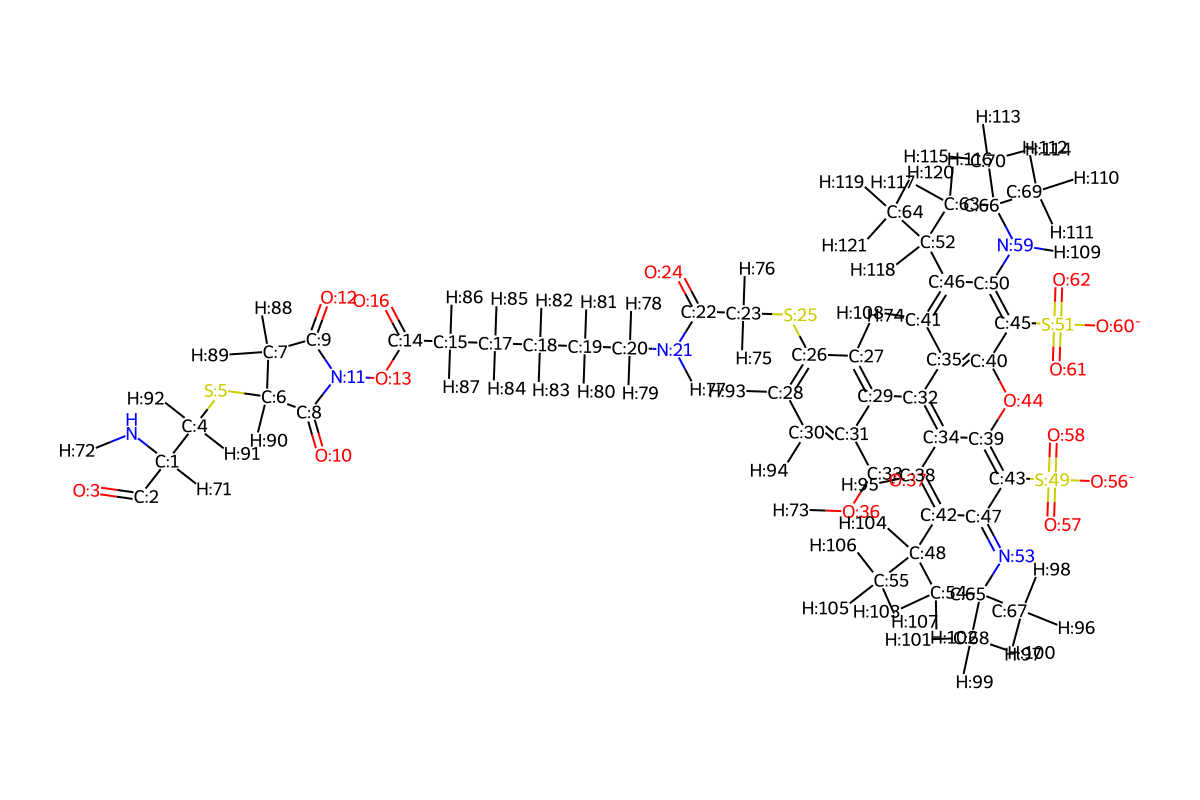

In [27]:
pt.draw_mol_with_atom_index(renamed_base[mon_name], size = (1200,800))

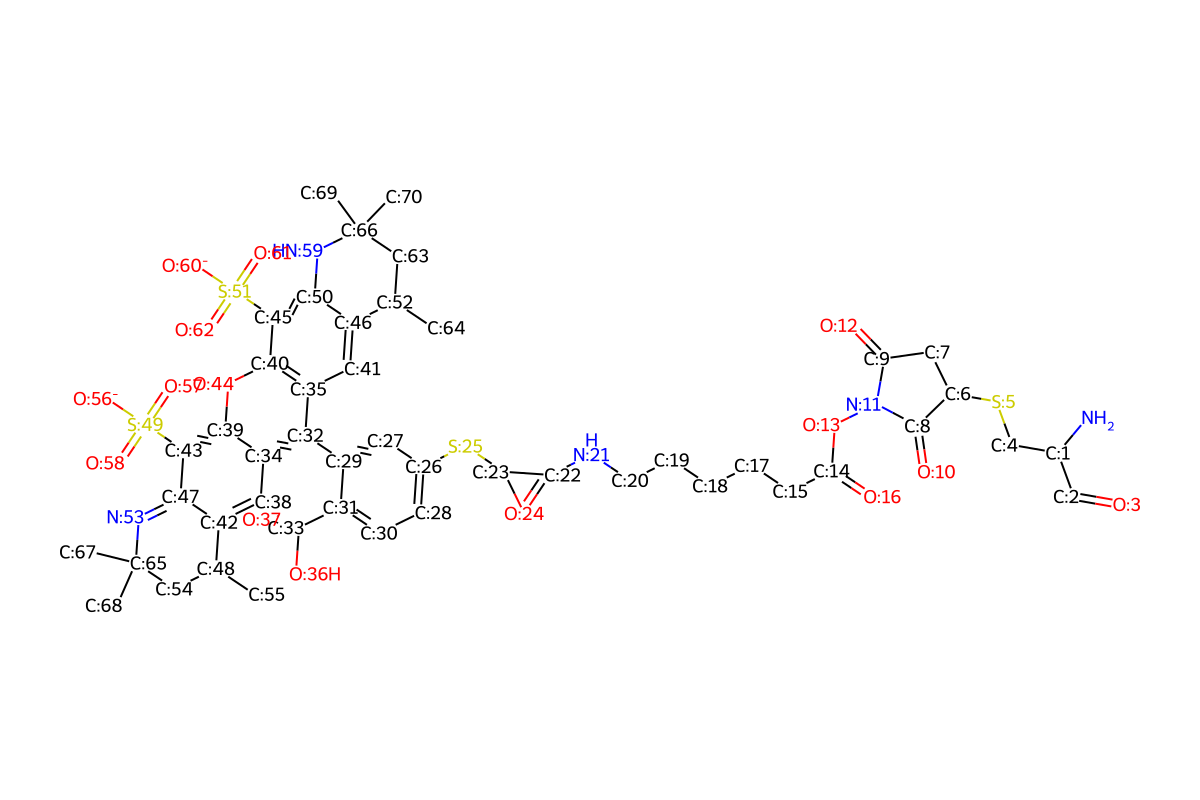

In [28]:
pt.draw_mol_with_atom_index(renamed_base[mon_name_no_H], size = (1200,800))

##### NGLview отрисовка

Поскольку мы сохранили pdb фаил то можно и через MDAnalysis и nglview посмотреть на него

In [56]:
nv.show_mdanalysis(mda.Universe(f'{PTM_name}/molecules/substructure/{mon_name}.pdb'))

ModuleNotFoundError: No module named 'nglview'

## Шаг 4 Переименовка атомов в составе остатка с присвоением канонических имен к каноничным атомам  

Полученные на шаге 3 были полученые структуры остатков. Данные структуры имеют как канонические атомы (т.е. входят в состав каноничных аминокислоты), так и не канонические -- новые. \
На шаге 4 мы находим соствае парметризуемого остатка канонические атомы, которыек сохранилди ориганльные валентности и присваиваем им канонические имена атомов.

In [7]:
# PTM_name = 'Lysine_Cro'
# mon_name = 'Kcr_H'

print(mon_name, pol_name, sep='\n')

C_AF_546
ACA_AF_546


### Сопоставление модифицированного остатка с референсными остатками

In [8]:
path_to_mod_aa = f'molecules/substructure/{mon_name}.pdb'

mod_aa_name = os.path.basename(path_to_mod_aa).split('.')[0]
print(mod_aa_name)
mod_aa_chem_dict = pt.pdb_to_chem(path_to_mod_aa)

ref_aa_chem_dict, match_data_dict = pt.find_ref_aa(mod_aa_chem_dict, 
                             path_to_ref_mol='../molecules/aminoacids_template',
                             ref_base_name = 'C', only_heavy_mapping = False,
                             match_residue_number = 2, 
                             main_match_data=True, timeout=3)   
ref_aa_chem_dict, match_data_dict

C_AF_546
Производится сопоставление с Cys
Выполнение Поиск подструктуры между молекулами.  

/trinity/home/_shared/_projects/2022_md_FRET_nv/AI_param_tool/notebooks_and_examples/param_tool.py:769: UserWarning: ⚠ MCS с явными протонами может быть очень медленным.
  warnings.warn("⚠ MCS с явными протонами может быть очень медленным.")



Поиск подструктуры между молекулами выполнен успешно!
../molecules/aminoacids_template/GCG_H.pdb
Reference amino acid is GCG_H, with 10 matched atoms.


({'GCG_H': <rdkit.Chem.rdchem.Mol at 0x1553f0295070>},
 {'substructure': {'GCG_H': <rdkit.Chem.rdchem.Mol at 0x1553f00e3220>},
  'N_match_atoms': {'GCG_H': 10},
  'mon_pol_matches': {'GCG_H': {72: 10,
    0: 9,
    1: 11,
    71: 12,
    4: 13,
    2: 18,
    91: 14,
    92: 15,
    5: 16,
    3: 19}},
  'mon_pol_atom_names': {'GCG_H': {'H': 'H',
    'N': 'N',
    'CA': 'CA',
    'HA': 'HA',
    'CB': 'CB',
    'C': 'C',
    'HB1': 'HB1',
    'HB2': 'HB2',
    'SG': 'SG',
    'O': 'O'}}})

In [9]:
ref_aa_chem_dict, match_data_dict

({'GCG_H': <rdkit.Chem.rdchem.Mol at 0x1553f0295070>},
 {'substructure': {'GCG_H': <rdkit.Chem.rdchem.Mol at 0x1553f00e3220>},
  'N_match_atoms': {'GCG_H': 10},
  'mon_pol_matches': {'GCG_H': {72: 10,
    0: 9,
    1: 11,
    71: 12,
    4: 13,
    2: 18,
    91: 14,
    92: 15,
    5: 16,
    3: 19}},
  'mon_pol_atom_names': {'GCG_H': {'H': 'H',
    'N': 'N',
    'CA': 'CA',
    'HA': 'HA',
    'CB': 'CB',
    'C': 'C',
    'HB1': 'HB1',
    'HB2': 'HB2',
    'SG': 'SG',
    'O': 'O'}}})

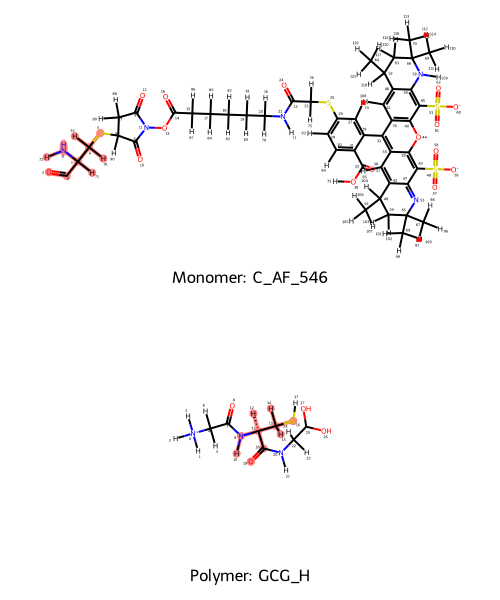

In [10]:
pt.draw_mon_pol_match(mod_aa_chem_dict, ref_aa_chem_dict, match_data_dict, 
                      add_small_atom_index=True, prefer_coord_gfen = False)

In [11]:
pt.save_json('general_atoms', list(*match_data_dict['mon_pol_atom_names'].values()), )

Файл успешно сохранен: 
/trinity/home/_shared/_projects/2022_md_FRET_nv/AI_param_tool/notebooks_and_examples/AF_546_cys/general_atoms.json


### Переименовка атомов в модифицированном остатке

In [ ]:
from collections import Counter

from rdkit import Chem
from rdkit.Chem import AllChem

def check_PDB_residue_info(atom):
    """
    Проверяет, что параметры остатка были правильно установлены для атома.
    """
    monomer_info = atom.GetMonomerInfo()
    # assert monomer_info.IsValid(), "Информация об остатке не установлена!"
    assert monomer_info.GetName().strip(), "Имя атома не установлено!"
    assert monomer_info.GetResidueName().strip(), "Имя остатка не установлено!"
    assert monomer_info.GetResidueNumber() >= 1, "Номер остатка не установлен!"
    assert monomer_info.GetChainId().strip(), "ID сегмента не установлен!"
    print(f"Параметры остатка для атома {monomer_info.GetName()} установлены корректно.", 
          monomer_info.GetName(), 
          monomer_info.GetResidueName(),
        monomer_info.GetResidueNumber(),
        monomer_info.GetChainId(),sep='\n')

def check_duplicate_atom_names(mol):
    """
    Проверяет наличие атомов с одинаковыми именами в молекуле и возвращает словарь.
    """
    # Получаем список всех имен атомов
    atom_names = [atom.GetProp('AtomName') for atom in mol.GetAtoms()]

    # Подсчитываем частоту появления каждого имени
    name_count = Counter(atom_names)
    print(name_count)
    # Формируем словарь с именами атомов и их индексами в молекуле
    atom_indices = {}
    for i, atom in enumerate(mol.GetAtoms()):
        name = atom.GetProp('AtomName')
        if name in atom_indices:
            atom_indices[name].append(i)
        else:
            atom_indices[name] = [i]

    # Отбираем только те атомы, которые имеют одинаковые имена
    duplicates = {name: indices for name, indices in atom_indices.items() if len(indices) > 1}

    if duplicates:
        print("Обнаружены атомы с одинаковыми именами:")
        for name, indices in duplicates.items():
            print(f"Имя: '{name}', Индексы атомов: {indices}")
    else:
        print("Дубликаты имен атомов не найдены.")

    return duplicates

def set_PDB_residue_info(atom, atom_name, resname='MOD', resid=1, segid='A'):
    
    info = Chem.AtomPDBResidueInfo()
    info.SetName(atom_name.ljust(4))        # Имя должно быть ровно 4 символа
    info.SetResidueName(resname)            # Устанавливаем имя остатка
    info.SetResidueNumber(resid)            # Устанавливаем номер остатка
    info.SetChainId(segid)                  # Устанавливаем ID сегмента
    atom.SetMonomerInfo(info)
    # return info
    

def modifie_residue_info(modified_mol,  index_map, resname='MOD', resid=1, segid='A'):
    """
    Назначает новые имена атомам в молекуле согласно индексному отображению.
    """
    # ref_mol_atom_dict = {atom.GetIdx(): atom.GetProp('AtomName') for atom in reference_mol.GetAtoms() if atom.GetPDBResidueInfo().GetResidueNumber()==2 }
    
    for atom in modified_mol.GetAtoms():
        atom_name = atom.GetProp('AtomName') 
        
        if atom_name in index_map.keys():
            atom_name = index_map[atom_name]
            atom.SetProp("AtomName", atom_name)
            print(f'Имя атома {atom.GetSymbol()} с индексом {atom.GetIdx()} заменено на имя {atom_name} ')
            set_PDB_residue_info(atom, atom_name, resname, resid, segid) 
        else:
            ref_names = set(index_map.values()) 
            new_name = atom_name
            if atom_name in ref_names:
                while new_name in ref_names:
                    new_name = increment_name(new_name)
                print(f'Имя атома {atom_name} с индексом {atom.GetIdx()} заменено на имя {new_name} ')
            set_PDB_residue_info(atom, atom_name, resname, resid, segid)
    return modified_mol

def increment_name(name):
    match = re.match(r'(\D+)(?:(\d*))$', name)
    if match:
        base, num_str = match.groups()
        num = int(num_str or '0')
        return f'{base}{num + 1}'
    else:
        return f'{name}1' # это странно, типа для случая CH1A 

def write_modified_molecule(mol, output_path):
    """
    Записывает измененную молекулу в PDB-файл.
    """
    writer = Chem.PDBWriter(output_path)
    for atom in mol.GetAtoms():
        atom.SetMonomerType(atom.GetProp('AtomName'))
    writer.write(mol)
    writer.close()
    
def save_molecule_as_pdb(molecule, filename, format_coord='3D'):
    """
    Сохраняет молекулу в формате PDB.

    :param molecule: Молекула в формате RDKit Mol.
    :param filename: Имя файла для сохранения.
    :param format: Формат представления ('2D' или '3D'). По умолчанию '3D'.
    """
    if format_coord == '2D':
        # Рассчитываем 2D координаты
        AllChem.Compute2DCoords(molecule)
    elif format_coord == '3D':
        # Рассчитываем 3D координаты (если еще не рассчитаны)
        Chem.SanitizeMol(molecule)
        AllChem.EmbedMolecule(molecule)
        AllChem.UFFOptimizeMolecule(molecule)
    else:
        raise ValueError("Недопустимый формат. Выберите '2D' или '3D'.")
    
    path_to_file, file_name = pt.path_parser(filename, ['pdb'])
    save_path = f'{path_to_file}/{file_name}_{format_coord}.pdb'
    # Сохраняем молекулу в PDB формате
    with open(save_path, 'w') as pdb_file:
        pdb_file.write(Chem.MolToPDBBlock(molecule))
    print(f"Молекула успешно сохранена в файле {save_path} в формате {format_coord}.")

def add_names_from_residue(modified_chem, index_map, resname='MOD', resid=1, segid='A'):
    # Загружаем молекулы

    
    mod_mol = list(modified_chem.values())[0] # костыль работы с словарем молекулы
    # ref_mol = list(reference_chem.values())[0] # костыль работы с словарем молекулы
   

    key_map = next(iter(match_data_dict['mon_pol_matches'].keys()))
    index_map = match_data_dict['mon_pol_matches'][key_map]
    # Присваиваем новые имена атомам в модифицированной молекуле
    # Перезадаем параметры модифицированного остатка  
    mod_residue = modifie_residue_info(mod_mol, index_map, resname, resid, segid)
    
    # Проверка наличия дублирующих имен атомов
    has_duplicates = check_duplicate_atom_names(mod_residue)
    # print(has_duplicates)
    
    return mod_residue

In [12]:
key_map = next(iter(match_data_dict['mon_pol_matches'].keys()))
match_data_dict['mon_pol_matches'][key_map]

{72: 10, 0: 9, 1: 11, 71: 12, 4: 13, 2: 18, 91: 14, 92: 15, 5: 16, 3: 19}

In [13]:
modifie_residue = pt.add_names_from_residue(mod_aa_chem_dict,
                       match_data_dict,
                        resid = 2,
                        resname = base_name,)

Дубликаты имен атомов не найдены.


In [14]:
save_molecule_as_pdb(modifie_residue, f'molecules/substructure/{PTM_name}_rn.pdb', format_coord='3D')

NameError: name 'save_molecule_as_pdb' is not defined

In [ ]:
modifie_residue

### Шаг 4.1. Протонирование атомов, потерявших стандартную валентность 

Этот шаг необходим для дальнейшего получения файла itp для нашей а.к. \
Дело в том, что acpype отказывается создавать топологию для атомов с нестандартными валентностями, что вполне логично. Поэтому мы добавляем протоны, которых на самом деле нет в остатке. После в процесе редактирвоания itp мы удалим все строки с лишними протонами. \
Стоит отметить, что этот шаг можно также выполнить с использованием любого удобного вам молекулярного редактора (ChimeraX, PyMOL) взяв за основу pdb фаийл сохраненный на 3-ем шаге.

In [19]:
H_modifie_residue = pt.add_protons_and_renumber_H(renamed_base[mon_name], resname = base_name, resid=2, segid='A')

Для атома 122 присвоено имя HW1
Для атома 123 присвоено имя HW2


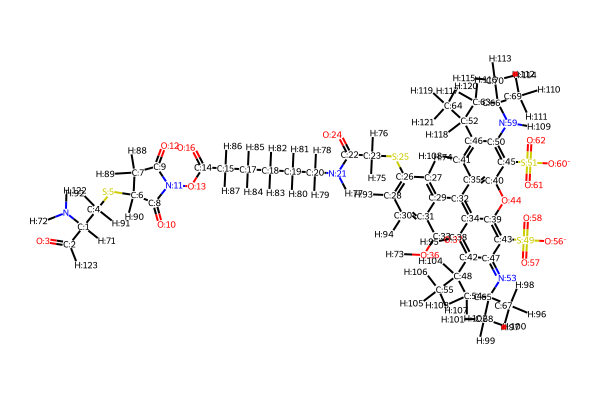

In [20]:
pt.draw_mol_with_atom_index(H_modifie_residue)

In [21]:
for atom in H_modifie_residue.GetAtoms():
    info = atom.GetPDBResidueInfo()
    print(info.GetResidueNumber(), info.GetResidueName(), atom.GetProp('AtomName'), atom.GetIdx(), atom.GetAtomMapNum())

2 546 N 0 0
2 546 CA 1 1
2 546 C 2 2
2 546 O 3 3
2 546 CB 4 4
2 546 SG 5 5
2 546 CD 6 6
2 546 CE1 7 7
2 546 CE2 8 8
2 546 CZ1 9 9
2 546 OZ2 10 10
2 546 NZ3 11 11
2 546 OH1 12 12
2 546 OH2 13 13
2 546 CT 14 14
2 546 CI1 15 15
2 546 OI2 16 16
2 546 CK 17 17
2 546 C19 18 18
2 546 C20 19 19
2 546 C21 20 20
2 546 N22 21 21
2 546 C23 22 22
2 546 C24 23 23
2 546 O25 24 24
2 546 S26 25 25
2 546 C27 26 26
2 546 C28 27 27
2 546 C29 28 28
2 546 C30 29 29
2 546 C31 30 30
2 546 C32 31 31
2 546 C33 32 32
2 546 C34 33 33
2 546 C35 34 34
2 546 C36 35 35
2 546 O37 36 36
2 546 O38 37 37
2 546 C39 38 38
2 546 C40 39 39
2 546 C41 40 40
2 546 C42 41 41
2 546 C43 42 42
2 546 C44 43 43
2 546 O45 44 44
2 546 C46 45 45
2 546 C47 46 46
2 546 C48 47 47
2 546 C49 48 48
2 546 S50 49 49
2 546 C51 50 50
2 546 S52 51 51
2 546 C53 52 52
2 546 N54 53 53
2 546 C55 54 54
2 546 C56 55 55
2 546 O57 56 56
2 546 O58 57 57
2 546 O59 58 58
2 546 N60 59 59
2 546 O61 60 60
2 546 O62 61 61
2 546 O63 62 62
2 546 C64 63 63
2 546 C6

In [22]:
pt.save_molecule_as_pdb(H_modifie_residue, f'molecules/substructure/{PTM_name}_rn_H.pdb', format_coord='3D')

Молекула успешно сохранена в файле molecules/substructure/C_AF546_rn_H_3D.pdb в формате 3D.


In [23]:
pt.save_aa_chem_to_smiles(H_modifie_residue, f'molecules/substructure/{PTM_name}_rn_H.smiles', canonical=False ,make_N_root=False)

C_AF546_rn_Hles.smiles saved to molecules/substructure


In [37]:
test = mda.Universe(f'{PTM_name}/molecules/substructure/{PTM_name}_rn_H_3D.pdb')
nv.show_mdanalysis(test)

NameError: name 'mda' is not defined

## Шаг 5. Расчет зарядов при помощи библиотеки Espaloma Charge

На вход: 
- Молекула-ы в виде тримеров в формате smiles. 

Задача ограничейни зарядов для одной молекулы


Создание ограничений

In [24]:
!pwd

/trinity/home/_shared/_projects/2022_md_FRET_nv/AI_param_tool/notebooks_and_examples/AF_546_cys


In [6]:
PTM_name

'C_AF546'

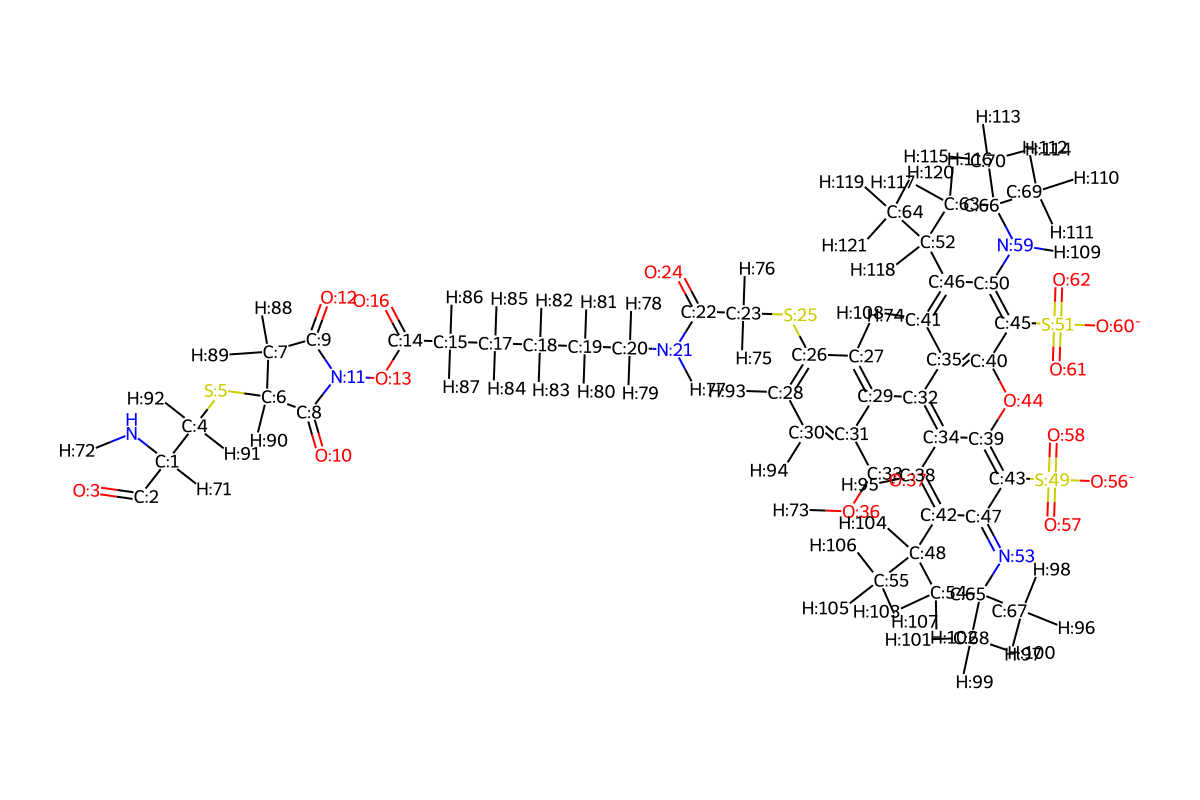

In [7]:
residue = pt.pdb_to_chem(f'molecules/substructure/{mon_name}.pdb')
pt.draw_mol_with_atom_index(residue[mon_name], size = (1200,800))

In [8]:
constraint_dict = {f'{mon_name}':
                  {'symmetric_list': [],
                   'charge_atom_dict': {0:-0.41570, 72:0.27190, 
                                        1:0.02130, 2:0.59730, 
                                        3:-0.56790, 71:0.11240},
                   'charge_of_monomer': -2.0000,
                  }
                  }

### Расчет зарядов при помощи библиотеки Espaloma Charge

In [9]:
sys.path.append(os.path.abspath("../../espaloma-charge_mod/"))
sys.path.append(os.path.abspath('../')) 
import param_tool as pt
from espaloma_charge import charge

In [10]:
charges = charge(residue[mon_name], 
                 constraints=constraint_dict[mon_name]['charge_atom_dict']
                )

print(f'Суммарный заряд молекулы: {sum(charges)}', charges, sep = '\n')


/trinity/home/n_kristovsky/.conda/envs/darwin_ec/lib/python3.12/site-packages/dgl/heterograph.py:92: DGLWarning: Recommend creating graphs by `dgl.graph(data)` instead of `dgl.DGLGraph(data)`.
  dgl_warning(


Суммарный заряд молекулы: -1.9999980218708515
[-0.4157      0.0213      0.5973     -0.5679     -0.20600139  0.6095663
 -0.12859784 -0.27260405  0.5176593   0.5129938  -0.36646792 -0.3283702
 -0.36075723 -0.05956737  0.4361371  -0.23002942 -0.51309353 -0.19435503
 -0.20174265 -0.19299209  0.01217765 -0.59875184  0.5435167  -0.23531803
 -0.44571102  0.6564787  -0.05732968 -0.44808677 -0.49662092 -0.09601313
 -0.40564546 -0.21030933 -0.31748086  0.74259615 -0.12705043 -0.11597595
 -0.7053632  -0.38794908 -0.37399286  0.00597233 -0.00693019 -0.46126637
 -0.33440188 -0.35929483 -0.35491    -0.30542183 -0.28907374  0.24492443
 -0.19859281  1.6054282   0.09333269  1.601886   -0.21714151 -0.6169964
 -0.24419929 -0.35822108 -0.6229094  -0.7166386  -0.7166386  -0.6250878
 -0.61666316 -0.70958275 -0.70958275 -0.28468496 -0.35745716 -0.07412586
 -0.05983036 -0.2803534  -0.2803534  -0.33846542 -0.33846542  0.1124
  0.2719      0.40052363  0.21229887  0.17633155  0.17633155  0.3826947
  0.13108227  

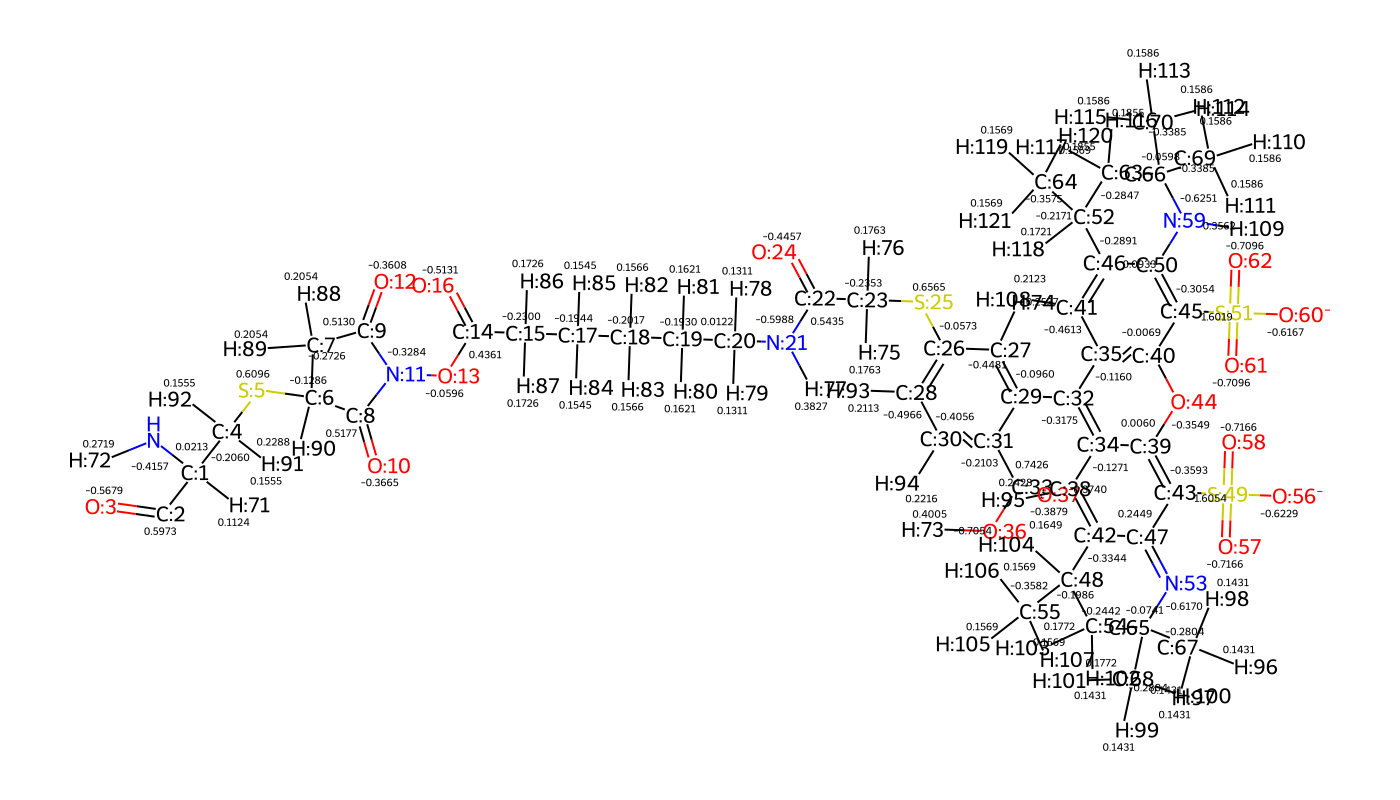

In [11]:
pt.draw_mol_with_atom_index(residue[mon_name], charge_list=charges, size = (1400,800))

## Сохранение масcива зарядов

In [12]:
pt.save_charges_json(name = f'AI_chrges_{mon_name}', charge_list = charges.tolist(),  )

Файл успешно сохранен: 
/trinity/home/_shared/_projects/2022_md_FRET_nv/AI_param_tool/notebooks_and_examples/AF_546_cys/AI_chrges_C_AF_546.json


#### 1.7. Проверка сохраненных зарядов 

In [13]:
with open('AI_chrges_C_AF_546.json', 'r') as f:
    charges = json.load(f)

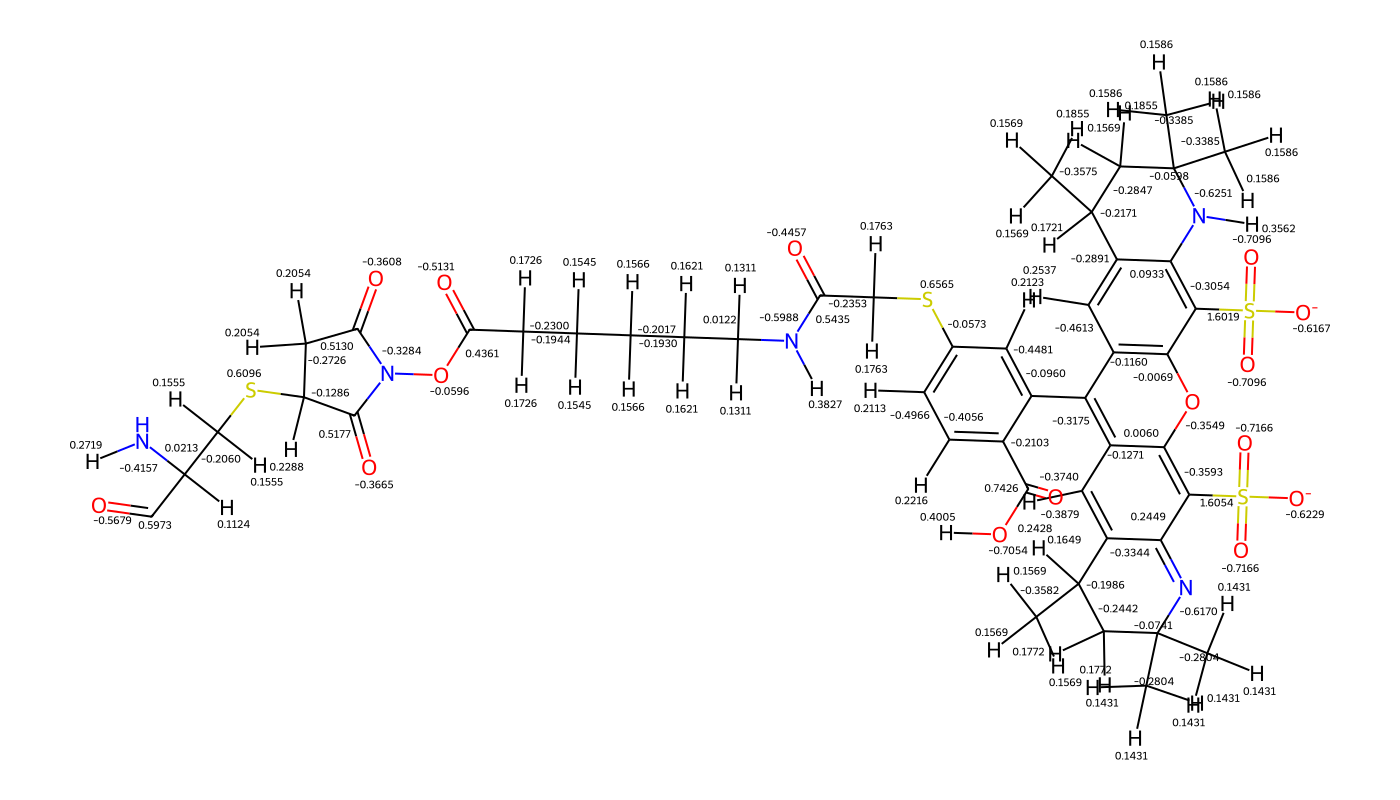

In [14]:
residue = pt.pdb_to_chem(f'molecules/substructure/{mon_name}.pdb')
pt.draw_mol_with_atom_index(residue[mon_name], charge_list=charges, size = (1400,800))

In [11]:
residue

{'C_AF_546': <rdkit.Chem.rdchem.Mol at 0x1553ec0b03c0>}

In [13]:
from openbabel import pybel, openbabel

# 1. Загружаем PDB
# Используем pybel для удобного чтения
mol = next(pybel.readfile("pdb", f'molecules/substructure/{mon_name}.pdb'))

# 3. Применяем заряды и сохраняем имена
# Обращаемся к низкоуровневому объекту OBMol
ob_mol = mol.OBMol

for i, atom in enumerate(openbabel.OBMolAtomIter(ob_mol)):
    # Устанавливаем частичный заряд из вашего списка
    atom.SetPartialCharge(charges[i])
    
    # Чтобы сохранить имена из PDB (например, 'CA', 'FE'), 
    # убедимся, что Open Babel не перезаписал их при импорте.
    # Обычно они уже сидят в GetResidue().GetAtomID(atom)
    res = atom.GetResidue()
    if res:
        name = res.GetAtomID(atom).strip()
        # Если нужно принудительно зафиксировать имя для MOL2:
        atom.SetType(name) 

# 4. Сохраняем в MOL2
# Опция "c" в write() заставляет Open Babel использовать частичные заряды из файла
mol.write("mol2", f'molecules/substructure/{mon_name}.mol2', overwrite=True)

*** Open Babel Warning  in Translate
  Cannot perform atom type translation: table cannot find requested types.
*** Open Babel Warning  in Translate
  Cannot perform atom type translation: table cannot find requested types.
*** Open Babel Warning  in Translate
  Cannot perform atom type translation: table cannot find requested types.
*** Open Babel Warning  in Translate
  Cannot perform atom type translation: table cannot find requested types.
*** Open Babel Warning  in Translate
  Cannot perform atom type translation: table cannot find requested types.
*** Open Babel Warning  in Translate
  Cannot perform atom type translation: table cannot find requested types.
*** Open Babel Warning  in Translate
  Cannot perform atom type translation: table cannot find requested types.
*** Open Babel Warning  in Translate
  Cannot perform atom type translation: table cannot find requested types.
*** Open Babel Warning  in Translate
  Cannot perform atom type translation: table cannot find requested